# Deep Learning Project

## Imports

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import cv2
import os

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch.optim as optim
import torch.nn as nn
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from models.classifiers.NN.NN_1 import DeepFakeNN_1

## Load Dataset

In [12]:
#  Grab all the real images from the 'wiki' folder
real_images = glob("data/wiki/**/*.jpg", recursive=True)

# Grab all the fake images from the other three folders
fake_images_dict = {}
total_fake_count = 0
for folder in ["inpainting", "insight", "text2img"]:
    paths = glob(f"data/{folder}/**/*.jpg", recursive=True)
    fake_images_dict[folder] = paths
    total_fake_count += len(paths)

print(f"Total Real Images found: {len(real_images)}")
print(f"Total Fake Images found: {total_fake_count}")

for folder, paths in fake_images_dict.items():
    print(f"  - {folder}: {len(paths)}")

Total Real Images found: 30000
Total Fake Images found: 90000
  - inpainting: 30000
  - insight: 30000
  - text2img: 30000


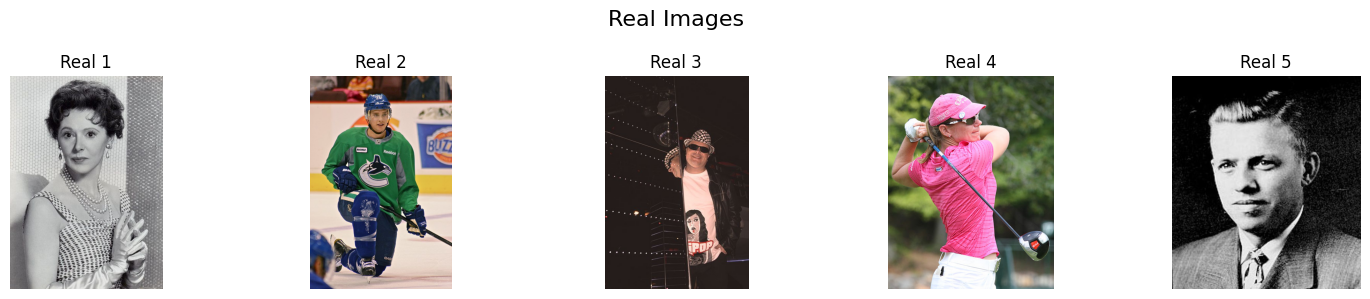

In [13]:
first_5_real = real_images[:5]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle("Real Images", fontsize=16)

for i, path in enumerate(first_5_real):
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img_rgb)
    axes[i].set_title(f"Real {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

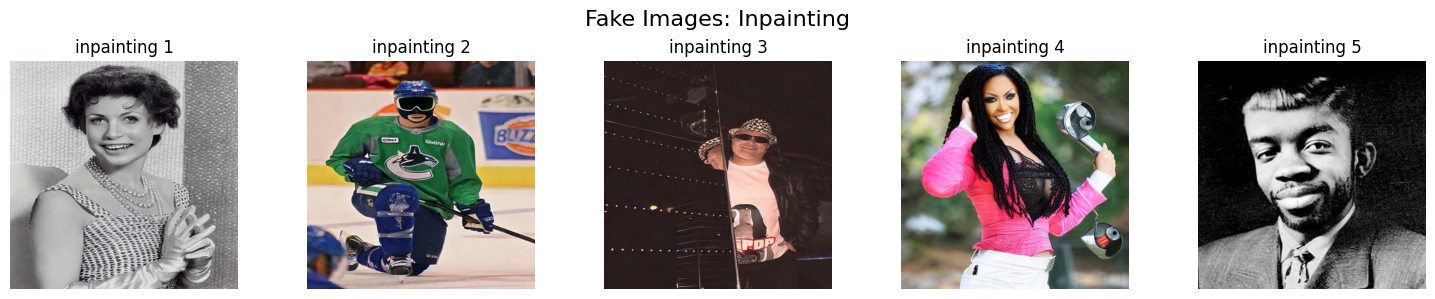

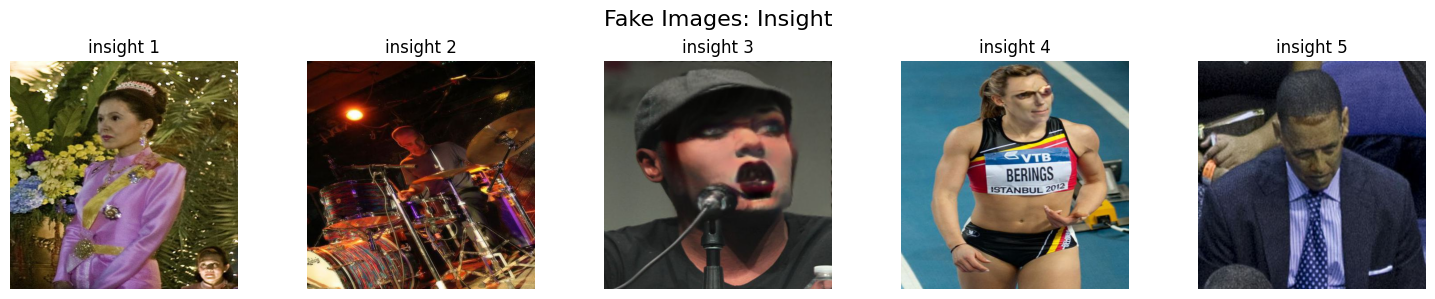

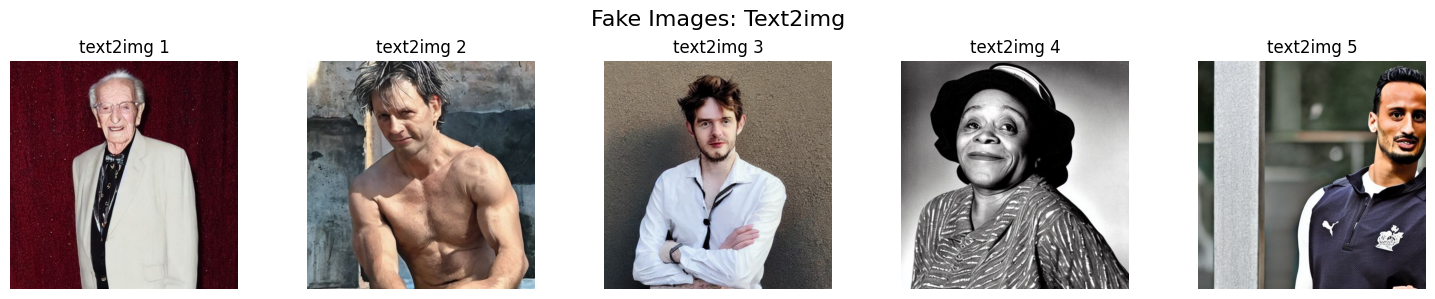

In [14]:
for folder_name, paths in fake_images_dict.items():

    first_5_category = paths[:5]

    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    fig.suptitle(f"Fake Images: {folder_name.capitalize()}", fontsize=16)

    for i, path in enumerate(first_5_category):
        img = cv2.imread(path)

        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i].imshow(img_rgb)

        axes[i].set_title(f"{folder_name} {i+1}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

## Preprocessing

In [15]:
class DeepFakeDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, 'filepath']
        label = self.dataframe.loc[idx, 'label']

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label = torch.tensor([label], dtype=torch.float32)

        return image, label

In [16]:
def create_preprocessing_pipeline(real_list, fake_dict, batch_size=32, img_size=(224, 224), fake_index=3):
    """
    Takes lists of real and fake images, builds dataframes, splits the data,
    and returns PyTorch DataLoaders and the split DataFrames.

    fake_index:
        0 = use first fake category
        1 = use second fake category
        2 = use third fake category
        3 = use ALL fake categories
    """

    print("Building DataFrames...")
    # Create Real DataFrame
    df_real = pd.DataFrame({'filepath': real_list, 'label': 0, 'source': 'wiki'})

    # Determine which fake folders to use based on fake_index
    folder_names = list(fake_dict.keys())

    if fake_index == 3:
        folders_to_use = folder_names
        print("Using ALL fake categories.")
    elif 0 <= fake_index <= 2:
        folders_to_use = [folder_names[fake_index]]
        print(f"Using ONLY fake category: {folders_to_use[0]}")
    else:
        raise ValueError("fake_index must be 0, 1, 2, or 3")

    # Create Fake DataFrame
    fake_dfs = []
    for folder_name in folders_to_use:
        paths = fake_dict[folder_name]
        df = pd.DataFrame({'filepath': paths, 'label': 1, 'source': folder_name})
        fake_dfs.append(df)

    df_fake = pd.concat(fake_dfs, ignore_index=True)

    # Combine into full dataset
    df_full = pd.concat([df_real, df_fake], ignore_index=True)

    print("Splitting Data (70% Train, 15% Val, 15% Test)...")
    train_df, temp_df = train_test_split(
        df_full, test_size=0.30, random_state=42, stratify=df_full['label']
    )

    val_df, test_df = train_test_split(
        temp_df, test_size=0.50, random_state=42, stratify=temp_df['label']
    )

    print("Setting up Transforms and DataLoaders...")
    data_transform = transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor()
    ])

    # Create Datasets
    train_dataset = DeepFakeDataset(train_df, transform=data_transform)
    val_dataset = DeepFakeDataset(val_df, transform=data_transform)
    test_dataset = DeepFakeDataset(test_df, transform=data_transform)

    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    print("Pipeline Complete!\n")

    return train_loader, val_loader, test_loader, train_df, val_df, test_df

## Model Training

In [17]:
def compute_binary_metrics(all_labels, all_preds, all_probs):
    accuracy = (np.array(all_preds) == np.array(all_labels)).mean() * 100
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    try:
        roc_auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        roc_auc = float("nan")

    tn, fp, fn, tp = confusion_matrix(all_labels, all_preds, labels=[0, 1]).ravel()

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn
    }

In [18]:
def evaluate_model(model, data_loader, criterion, device):
    model.eval()
    running_loss = 0.0

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            if labels.dim() == 1:
                labels = labels.unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()

            all_labels.extend(labels.cpu().numpy().flatten())
            all_preds.extend(preds.cpu().numpy().flatten())
            all_probs.extend(probs.cpu().numpy().flatten())

    epoch_loss = running_loss / len(data_loader)
    metrics = compute_binary_metrics(all_labels, all_preds, all_probs)
    metrics["loss"] = epoch_loss

    return metrics


In [19]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, experiment_name, model_name,epochs=5):
    """
    Trains the model on train_loader.
    Evaluates on val_loader after each epoch.
    Logs results into experiment_logs/{model_name}.txt
    """
    print(f"Starting experiment: {experiment_name}")

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "train_precision": [],
        "train_recall": [],
        "train_f1": [],
        "train_roc_auc": [],
        "train_tp": [],
        "train_tn": [],
        "train_fp": [],
        "train_fn": [],

        "val_loss": [],
        "val_accuracy": [],
        "val_precision": [],
        "val_recall": [],
        "val_f1": [],
        "val_roc_auc": [],
        "val_tp": [],
        "val_tn": [],
        "val_fp": [],
        "val_fn": []
    }

    log_dir = "experiment_logs"
    os.makedirs(log_dir, exist_ok=True)
    log_filepath = os.path.join(log_dir, f"{model_name}.txt")

    with open(log_filepath, "a") as f:
        f.write(f"Experiment: {experiment_name}\n")
        f.write("-" * 40 + "\n")
        f.flush() 

        for epoch in range(epochs):
            model.train()
            running_loss = 0.0

            all_labels = []
            all_preds = []
            all_probs = []

            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)

                if labels.dim() == 1:
                    labels = labels.unsqueeze(1)

                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                probs = torch.sigmoid(outputs)
                preds = (probs >= 0.5).float()

                all_labels.extend(labels.detach().cpu().numpy().flatten())
                all_preds.extend(preds.detach().cpu().numpy().flatten())
                all_probs.extend(probs.detach().cpu().numpy().flatten())

            train_loss = running_loss / len(train_loader)
            train_metrics = compute_binary_metrics(all_labels, all_preds, all_probs)
            train_metrics["loss"] = train_loss

            val_metrics = evaluate_model(model, val_loader, criterion, device)

            history["train_loss"].append(train_metrics["loss"])
            history["train_accuracy"].append(train_metrics["accuracy"])
            history["train_precision"].append(train_metrics["precision"])
            history["train_recall"].append(train_metrics["recall"])
            history["train_f1"].append(train_metrics["f1"])
            history["train_roc_auc"].append(train_metrics["roc_auc"])
            history["train_tp"].append(train_metrics["tp"])
            history["train_tn"].append(train_metrics["tn"])
            history["train_fp"].append(train_metrics["fp"])
            history["train_fn"].append(train_metrics["fn"])

            history["val_loss"].append(val_metrics["loss"])
            history["val_accuracy"].append(val_metrics["accuracy"])
            history["val_precision"].append(val_metrics["precision"])
            history["val_recall"].append(val_metrics["recall"])
            history["val_f1"].append(val_metrics["f1"])
            history["val_roc_auc"].append(val_metrics["roc_auc"])
            history["val_tp"].append(val_metrics["tp"])
            history["val_tn"].append(val_metrics["tn"])
            history["val_fp"].append(val_metrics["fp"])
            history["val_fn"].append(val_metrics["fn"])

            # Format and save the epoch results to the file
            log_entry = (
                f"Epoch {epoch+1}:\n"
                f"  TRAIN -> "
                f"Loss {train_metrics['loss']:.4f}, "
                f"Accuracy {train_metrics['accuracy']:.2f}%, "
                f"Precision {train_metrics['precision']:.4f}, "
                f"Recall {train_metrics['recall']:.4f}, "
                f"F1 {train_metrics['f1']:.4f}, "
                f"ROC-AUC {train_metrics['roc_auc']:.4f}, "
                f"TP {train_metrics['tp']}, TN {train_metrics['tn']}, "
                f"FP {train_metrics['fp']}, FN {train_metrics['fn']}\n"
                f"  VAL   -> "
                f"Loss {val_metrics['loss']:.4f}, "
                f"Accuracy {val_metrics['accuracy']:.2f}%, "
                f"Precision {val_metrics['precision']:.4f}, "
                f"Recall {val_metrics['recall']:.4f}, "
                f"F1 {val_metrics['f1']:.4f}, "
                f"ROC-AUC {val_metrics['roc_auc']:.4f}, "
                f"TP {val_metrics['tp']}, TN {val_metrics['tn']}, "
                f"FP {val_metrics['fp']}, FN {val_metrics['fn']}\n"
            )
            f.write(log_entry)
            f.flush()

            print(f"Finished {log_entry.strip()}")

    return model,history

### NN

#### NN_1

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print("Using device:", device)
all_models = {}
all_histories = {}
all_test_metrics = {}

log_dir = "experiment_logs"
log_file = os.path.join(log_dir, "NN_1.txt")

folder_names = list(fake_images_dict.keys())

for fake_idx in range(4):
    if fake_idx == 3:
        experiment_name = "all_fakes"
    else:
        experiment_name = folder_names[fake_idx]

    if os.path.exists(log_file):
        with open(log_file, "r") as f:
            existing_logs = f.read()
            if f"Experiment: {experiment_name}" in existing_logs:
                print(f"Skipping {experiment_name.upper()}: Results already found in {log_file}")
                continue

    print(f"\n{'='*60}")
    print(f"STARTING EXPERIMENT: {experiment_name.upper()}")
    print(f"{'='*60}")

    # Create the data pipeline
    train_loader, val_loader, test_loader, train_df, val_df, test_df = create_preprocessing_pipeline(
        real_list=real_images,
        fake_dict=fake_images_dict,
        batch_size=32,
        img_size=(224, 224),
        fake_index=fake_idx
    )

    print(f"Number of training batches: {len(train_loader)}")
    print(f"Number of validation batches: {len(val_loader)}")
    print(f"Number of test batches:       {len(test_loader)}")

    # Initialize a fresh model
    model = DeepFakeNN_1().to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    trained_model, train_history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        experiment_name=experiment_name,
        model_name="NN_1"
    )

    test_metrics = evaluate_model(trained_model, test_loader, criterion, device)
    with open(log_file, "a", encoding="utf-8") as f:
        f.write(
            f"  TEST  -> "
            f"Loss {test_metrics['loss']:.4f}, "
            f"Accuracy {test_metrics['accuracy']:.2f}%, "
            f"Precision {test_metrics['precision']:.4f}, "
            f"Recall {test_metrics['recall']:.4f}, "
            f"F1 {test_metrics['f1']:.4f}, "
            f"ROC-AUC {test_metrics['roc_auc']:.4f}, "
            f"TP {test_metrics['tp']}, TN {test_metrics['tn']}, "
            f"FP {test_metrics['fp']}, FN {test_metrics['fn']}\n\n"
        )

    all_models[experiment_name] = trained_model
    all_histories[experiment_name] = train_history
    all_test_metrics[experiment_name] = test_metrics

print("\n ALL 4 EXPERIMENTS COMPLETED SUCESSFULLY!")

Using device: cuda

STARTING EXPERIMENT: INPAINTING
Building DataFrames...
Using ONLY fake category: inpainting
Splitting Data (70% Train, 15% Val, 15% Test)...
Setting up Transforms and DataLoaders...
Pipeline Complete!

Number of training batches: 1313
Number of validation batches: 282
Number of test batches:       282
Starting experiment: inpainting
Finished Epoch 1:
  TRAIN -> Loss 0.7309, Accuracy 50.24%, Precision 0.5018, Recall 0.6577, F1 0.5693, ROC-AUC 0.4999, TP 13811, TN 7289, FP 13711, FN 7189
  VAL   -> Loss 0.6932, Accuracy 50.01%, Precision 0.5001, Recall 0.9996, F1 0.6666, ROC-AUC 0.5001, TP 4498, TN 3, FP 4497, FN 2
Finished Epoch 2:
  TRAIN -> Loss 0.6933, Accuracy 50.26%, Precision 0.5022, Recall 0.6052, F1 0.5489, ROC-AUC 0.5018, TP 12710, TN 8400, FP 12600, FN 8290
  VAL   -> Loss 0.6932, Accuracy 50.00%, Precision 0.5000, Recall 0.0002, F1 0.0004, ROC-AUC 0.4999, TP 1, TN 4499, FP 1, FN 4499
Finished Epoch 3:
  TRAIN -> Loss 0.6932, Accuracy 49.53%, Precision 0.49